In [1]:
import os
import sys
import subprocess
from subprocess import Popen, PIPE
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
import logging
import tempfile
import json
import numpy as np
from scipy.sparse import csr_array, coo_array
from scipy.sparse.linalg import eigsh
import h5py
import matplotlib.pyplot as plt
from flax import nnx
from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, RuntimeEncoder, RuntimeDecoder
from qiskit_addon_sqd.qubit import solve_qubit, sort_and_remove_duplicates, project_operator_to_subspace
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
from heavyhex_qft.plaquette_dual import PlaquetteDual
from skqd_z2lgt.circuits import make_step_circuits, compose_trotter_circuits
from skqd_z2lgt.ising_dmrg import ising_dmrg, get_mps_probs
from skqd_z2lgt.recovery_learning import preprocess
from skqd_z2lgt.crbm import ConditionalRBM
from skqd_z2lgt.train_crbm import cd_meanloss, make_l2_loss_fn, train_crbm
from skqd_z2lgt.sqd import qiskit_sqd, sqd

# cuda_visible_devices = [1, 2, 4, 5, 6, 7]
cuda_visible_devices = list(range(1, 5))

logging.basicConfig(level=logging.WARNING)
LOG = logging.getLogger('skqd_z2lgt')
LOG.setLevel(logging.INFO)

script_dir = '/home/iiyama/src/qii-miyabi-kawasaki/algorithms/skqd_z2lgt/scripts/workflow'

In [2]:
def read_skqd_result(filename, groupname):
    with h5py.File(filename, 'r') as source:
        group = source[groupname]
        num_bits = group['num_plaq'][()]
        sqd_states = np.unpackbits(group['sqd_states'][()], axis=1)[:, :num_bits]
        data = group['ham_proj/data'][()]
        indices = group['ham_proj/indices'][()]
        indptr = group['ham_proj/indptr'][()]
        shape = (indptr.shape[0] - 1,) * 2
        ham_proj = csr_array((data, indices, indptr), shape=shape)
        energy = group['energy'][()]

    return sqd_states, ham_proj, energy

## Basic setup

In [3]:
output_filename = '/data/iiyama/2dz2/full_workflow_kawasaki_64plaq_K1.0_dt1overnp.h5'

# configuration = {
#     'lattice': '''
#   ^ ^ ^
#  * * * *
# * * * * *
#  * * * *
# * * * * *
#  * * * *
# * * * * *
#  * * * *
#   v v v
# ''',
#     'plaquette_energy': 0.8,
#     'delta_t': 0.5,
#     'num_steps': 5,
#     'shots': 100_000,
#     'basis_2q': 'cz',
#     'instance': 'ICEPP-dedicated-temp-prem-us',
#     'backend': 'ibm_pittsburgh'
# }
configuration = {
    'lattice': '''
*-*-*-*-*╷
 * * * * *
* * * * *╎
 * * * * *
* * * * *╎
 * * * * *
* * * * *╎
 * * * * *
*-*-*-*-*╵
''',
    'plaquette_energy': 1.,
    'delta_t': 1. / 64,
    'num_steps': 8,
    'shots': 100_000,
    'basis_2q': 'rzz',
    'instance': 'ICEPP-dedicated',
    'backend': 'ibm_kawasaki'
}



In [4]:
try:
    with h5py.File(output_filename, 'r') as source:
        for key in source['configuration'].keys():
            record = source[f'configuration/{key}'][()]
            if isinstance(record, bytes):
                record = record.decode()

            if (value := configuration.get(key)) is None:
                configuration[key] = record
            else:
                if ((isinstance(record, float) and not np.isclose(record, value))
                        or isinstance(record, (int, str)) and record != value):
                    raise ValueError(f'Wrong {key}!')

except FileNotFoundError:
    with h5py.File(output_filename, 'w-', libver='latest') as output_file:
        group = output_file.create_group('configuration')
        for key, value in configuration.items():
            group.create_dataset(key, data=value)

In [5]:
lattice = TriangularZ2Lattice(configuration['lattice'])

dual_lattice = PlaquetteDual(lattice)
ising_hamiltonian = dual_lattice.make_hamiltonian(configuration['plaquette_energy'])

num_link = lattice.num_links
num_vtx = lattice.num_vertices
num_plaq = lattice.num_plaquettes
LOG.info('Number of links: %d, vertices: %d, plaquettes: %d', num_link, num_vtx, num_plaq)

INFO:skqd_z2lgt:Number of links: 108, vertices: 45, plaquettes: 64


## Compute the approximate ground-state energy

In [6]:
with h5py.File(output_filename, 'r', swmr=True) as source:
    compute = 'dmrg' not in source

if compute:
    proc = subprocess.run(['python', f'{script_dir}/dmrg.py', output_filename],
                          capture_output=True, text=True, check=False)
    sys.stdout.write(proc.stdout)
    sys.stderr.write(proc.stderr)
    proc.check_returncode()

with h5py.File(output_filename, 'r', swmr=True) as source:
    dmrg_energy = source['dmrg/energy'][()]
    mps_states = source['dmrg/mps_states'][()]
    mps_probs = source['dmrg/mps_probs'][()]

print('DMRG energy:', dmrg_energy)

DMRG energy: -118.75952661101113


## Get the experiment data

In [7]:
with h5py.File(output_filename, 'r', swmr=True) as source:
    compute = 'data' not in source
    submit = 'experiment' not in source

if submit:
    proc = subprocess.run(['python', f'{script_dir}/experiment.py', output_filename],
                          capture_output=True, text=True, check=False)
    sys.stdout.write(proc.stdout)
    sys.stderr.write(proc.stderr)
    proc.check_returncode()

if compute:
    proc = subprocess.run(['python', f'{script_dir}/data.py', output_filename],
                          capture_output=True, text=True, check=False)
    sys.stdout.write(proc.stdout)
    sys.stderr.write(proc.stderr)
    proc.check_returncode()

with h5py.File(output_filename, 'r', swmr=True) as source:
    group = source['data']
    exp_vtx_data = np.unpackbits(group['exp_vtx_data'][()], axis=2)[..., :num_vtx]
    exp_plaq_data = np.unpackbits(group['exp_plaq_data'][()], axis=2)[..., :num_plaq]
    ref_vtx_data = np.unpackbits(group['ref_vtx_data'][()], axis=2)[..., :num_vtx]
    ref_plaq_data = np.unpackbits(group['ref_plaq_data'][()], axis=2)[..., :num_plaq]

## Test the SKQD accuracy without configuration recovery

In [8]:
with h5py.File(output_filename, 'r', swmr=True) as source:
    compute = 'skqd_raw' not in source

if compute:
    cmd = ['python', f'{script_dir}/skqd_raw.py', output_filename,
           '--gpu'] + list(map(str, cuda_visible_devices))
    proc = subprocess.run(cmd, capture_output=True, text=True, check=False)
    sys.stdout.write(proc.stdout)
    sys.stderr.write(proc.stderr)
    proc.check_returncode()

sqd_states_raw, ham_proj_raw, energy_raw = read_skqd_result(output_filename, 'skqd_raw')

LOG.info('Basis size: %d', sqd_states_raw.shape[0])
LOG.info('Matrix density %d', ham_proj_raw.data.shape[0])
LOG.info('Raw bitstrings energy: %f', energy_raw)

INFO:skqd_z2lgt:Basis size: 710556
INFO:skqd_z2lgt:Matrix density 1146590
INFO:skqd_z2lgt:Raw bitstrings energy: -115.062702


## Test SKQD with random plaquette flips

In [9]:
num_exps = 5
sqd_states_rnd = {}
ham_proj_rnd = {}
energy_rnd = {}

compute_iexp = []
for iexp in range(num_exps):
    with h5py.File(output_filename, 'r', swmr=True) as source:
        if f'skqd_rnd_{iexp}' not in source:
            compute_iexp.append(iexp)

if compute_iexp:
    cmd = ['python', f'{script_dir}/skqd_random.py', output_filename]
    cmd += [f'{iexp}' for iexp in compute_iexp]
    cmd += ['--gpu'] + list(map(str, cuda_visible_devices))
    cmd += ['--num-gen', '3']
    proc = subprocess.run(cmd, capture_output=True, text=True, check=False)
    sys.stdout.write(proc.stdout)
    sys.stderr.write(proc.stderr)
    proc.check_returncode()

for iexp in range(num_exps):
    result = read_skqd_result(output_filename, f'skqd_rnd_{iexp}')
    sqd_states_rnd[iexp] = result[0]
    ham_proj_rnd[iexp] = result[1]
    energy_rnd[iexp] = result[2]

    LOG.info('Experiment %d basis size: %d', iexp, sqd_states_rnd[iexp].shape[0])
    LOG.info('Matrix density %d', ham_proj_rnd[iexp].data.shape[0])
    LOG.info('Energy %f', energy_rnd[iexp])

INFO:skqd_z2lgt:Experiment 0 basis size: 3034116
INFO:skqd_z2lgt:Matrix density 4253306
INFO:skqd_z2lgt:Energy -115.510495
INFO:skqd_z2lgt:Experiment 1 basis size: 3033957
INFO:skqd_z2lgt:Matrix density 4246961
INFO:skqd_z2lgt:Energy -115.495690
INFO:skqd_z2lgt:Experiment 2 basis size: 3033898
INFO:skqd_z2lgt:Matrix density 4246182
INFO:skqd_z2lgt:Energy -115.498641
INFO:skqd_z2lgt:Experiment 3 basis size: 3033922
INFO:skqd_z2lgt:Matrix density 4246044
INFO:skqd_z2lgt:Energy -115.486467
INFO:skqd_z2lgt:Experiment 4 basis size: 3033709
INFO:skqd_z2lgt:Matrix density 4250315
INFO:skqd_z2lgt:Energy -115.503007


## Train CRBMs for configuration recovery

In [10]:
procs = {}
for istep in range(configuration['num_steps']):
    groupname = f'crbm_step{istep}'
    with h5py.File(output_filename, 'r', swmr=True) as source:
        compute = groupname not in source

    if compute:
        with tempfile.NamedTemporaryFile() as tfile:
            out_name = tfile.name

        cmd = ['python', f'{script_dir}/train_crbm.py', output_filename, f'{istep}',
               '--gpu', f'{cuda_visible_devices[istep % len(cuda_visible_devices)]}',
               '--out', out_name, '--num-epochs', '100', '--rtol', '2.']
        procs[istep] = (Popen(cmd, stdout=PIPE, stderr=PIPE, text=True), out_name)

for istep, (proc, name) in procs.items():
    stdout, stderr = proc.communicate()
    sys.stdout.write(stdout)
    sys.stderr.write(stderr)
    if proc.returncode != 0:
        raise subprocess.SubprocessError()
    with h5py.File(output_filename, 'r+') as out:
        del out[f'crbm_step{istep}']
        with h5py.File(name, 'r') as source:
            source.copy(f'crbm_step{istep}', out)
    os.unlink(name)

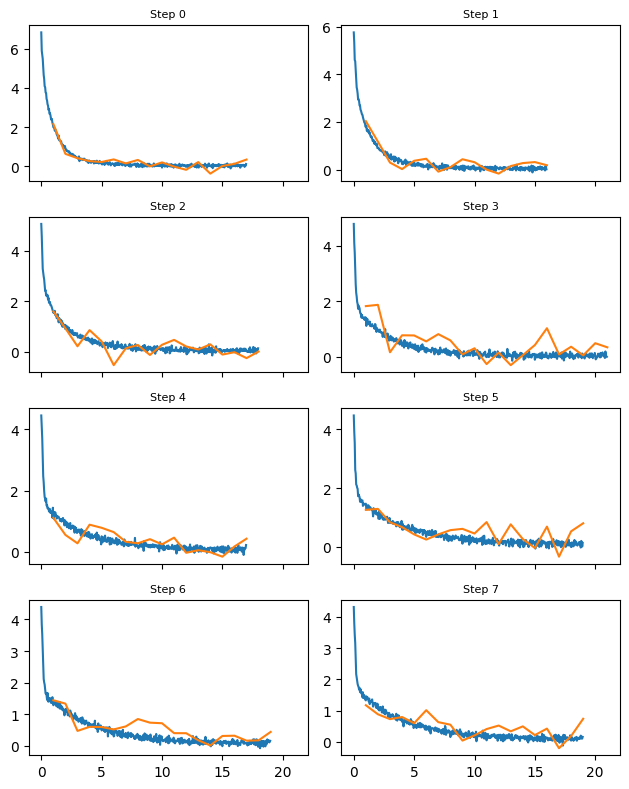

In [12]:
fig, axes = plt.subplots(4, np.ceil(configuration['num_steps'] / 4).astype(int), sharex=True)
fig.set_figheight(8.)

for istep in range(configuration['num_steps']):
    with h5py.File(output_filename, 'r') as source:
        train_loss = source[f'crbm_step{istep}/records/train_loss'][()]
        test_loss = source[f'crbm_step{istep}/records/test_loss'][()]

    evals_per_epoch = train_loss.shape[0] // test_loss.shape[0]

    ax = fig.axes[istep]
    ax.set_title(f'Step {istep}', fontsize=8)
    x = np.arange(len(train_loss)) / evals_per_epoch
    ax.plot(x, train_loss)
    x = np.arange(1, len(test_loss) + 1)
    ax.plot(x, test_loss)

fig.tight_layout()

## Test SKQD with configuration recovery

In [18]:
with h5py.File(output_filename, 'r', swmr=True) as source:
    compute = 'skqd_rcv' not in source

if compute:
    cmd = ['python', f'{script_dir}/skqd_recovery.py', output_filename,
           '--gpu', f'{cuda_visible_devices[0]}',
           '--num', '3', '--niter', '10',
           '--terminate', 'diff=0.05', 'dim=800000']
    proc = subprocess.run(cmd, capture_output=True, text=True)
    sys.stdout.write(proc.stdout)
    sys.stderr.write(proc.stderr)
    proc.check_returncode()

sqd_states_rcv, ham_proj_rcv, energy_rcv = read_skqd_result(output_filename, 'skqd_rcv')

LOG.info('Basis size: %d', sqd_states_rcv.shape[0])
LOG.info('Matrix density %d', ham_proj_rcv.data.shape[0])
LOG.info('Recovered bitstrings energy: %f', energy_rcv)

INFO:skqd_z2lgt:Basis size: 3174312
INFO:skqd_z2lgt:Matrix density 9196462
INFO:skqd_z2lgt:Recovered bitstrings energy: -116.491370


In [19]:
dmrg_energy, energy_raw, energy_rnd, energy_rcv

(np.float64(-118.75952661101113),
 np.float64(-115.06270181572201),
 {0: np.float64(-115.51049516771818),
  1: np.float64(-115.49569006728527),
  2: np.float64(-115.49864102010143),
  3: np.float64(-115.48646677954383),
  4: np.float64(-115.50300679575538)},
 np.float64(-116.49136956991305))